# Exploration des marchés de matières premières et benchmarks

Ce notebook télécharge les cours de contrats futures continus depuis **Yahoo Finance avec `yfinance`**, puis permet de :

- contrôler la qualité et la disponibilité des données ;
- comparer les marchés sur une base 100 ;
- analyser rendements, volatilité, corrélations et drawdowns ;
- construire un benchmark **Buy & Hold** pour chaque actif ;
- construire un **indice synthétique de matières premières** avec pondération égale ou inverse à la volatilité ;
- visualiser l'évolution des poids et comparer les performances ;
- exporter les datasets obtenus.

> **Attention méthodologique** : les tickers Yahoo Finance se terminant par `=F` représentent des séries continues. Ils ne reproduisent pas exactement un investissement réel dans des contrats datés, avec calendrier de roll, collatéral, marge et multiplicateurs. Le résultat est un benchmark de recherche adapté aux backtests, pas la réplication exacte d'un ETF investissable.

## 1. Imports

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Pandas :", pd.__version__)
print("yfinance :", yf.__version__)

Pandas : 2.2.3
yfinance : 1.4.1


## 2. Paramètres de l'analyse

Modifie uniquement cette cellule pour tester un autre univers ou une autre méthodologie d'indice.

In [2]:
# Période d'étude
START_DATE = "2015-01-01"
END_DATE = None                 # None = jusqu'à la date la plus récente disponible
PRICE_FIELD = "close"          # "close" ou "adj_close"

# Univers d'actifs
PRIORITIES = {"A"}             # {"A"}, {"A", "B"} ou {"A", "B", "C"}
ASSET_IDS = None                # Exemple : ["WTI", "GOLD", "COPPER", "COCOA"]

# Construction de l'indice synthétique
BASE_VALUE = 100.0
WEIGHTING = "equal"            # "equal" ou "inverse_vol"
REBALANCE = "monthly"          # "none", "monthly", "quarterly" ou "annual"
VOL_LOOKBACK = 60               # Fenêtre utilisée pour inverse_vol
MIN_VOL_OBSERVATIONS = 20
TRANSACTION_COST_BPS = 0.0      # Exemple : 5 = 5 points de base sur le turnover
ANNUAL_RISK_FREE_RATE = 0.0

# Nettoyage et alignement
MAX_FORWARD_FILL = 3            # Nombre maximal de séances reportées vers l'avant

# Actif utilisé dans certains graphiques détaillés
FOCUS_ASSET = "WTI"

# Export facultatif
OUTPUT_DIR = Path("data/notebook_outputs")
SAVE_OUTPUTS = False

## 3. Univers des matières premières

In [3]:
COMMODITIES: dict[str, dict[str, str]] = {
    "WTI": {"name": "Pétrole WTI", "ticker": "CL=F", "category": "Énergie", "priority": "A"},
    "GOLD": {"name": "Or", "ticker": "GC=F", "category": "Métaux précieux", "priority": "A"},
    "NATURAL_GAS": {"name": "Gaz naturel Henry Hub", "ticker": "NG=F", "category": "Énergie", "priority": "A"},
    "COPPER": {"name": "Cuivre", "ticker": "HG=F", "category": "Métaux industriels", "priority": "A"},
    "WHEAT": {"name": "Blé Chicago SRW", "ticker": "ZW=F", "category": "Agriculture", "priority": "A"},
    "CORN": {"name": "Maïs", "ticker": "ZC=F", "category": "Agriculture", "priority": "A"},
    "COCOA": {"name": "Cacao", "ticker": "CC=F", "category": "Soft commodities", "priority": "A"},
    "COFFEE": {"name": "Café Arabica", "ticker": "KC=F", "category": "Soft commodities", "priority": "A"},
    "BRENT": {"name": "Pétrole Brent", "ticker": "BZ=F", "category": "Énergie", "priority": "B"},
    "SILVER": {"name": "Argent", "ticker": "SI=F", "category": "Métaux précieux", "priority": "B"},
    "SOYBEAN": {"name": "Soja", "ticker": "ZS=F", "category": "Agriculture", "priority": "B"},
    "SUGAR": {"name": "Sucre No. 11", "ticker": "SB=F", "category": "Soft commodities", "priority": "B"},
    "PLATINUM": {"name": "Platine", "ticker": "PL=F", "category": "Métaux précieux", "priority": "C"},
    "PALLADIUM": {"name": "Palladium", "ticker": "PA=F", "category": "Métaux précieux", "priority": "C"},
    "COTTON": {"name": "Coton", "ticker": "CT=F", "category": "Agriculture", "priority": "C"},
}

PRICE_FIELD_MAP = {"close": "Close", "adj_close": "Adj Close"}
REBALANCE_PERIOD_MAP = {"monthly": "M", "quarterly": "Q", "annual": "Y"}

universe_df = (
    pd.DataFrame.from_dict(COMMODITIES, orient="index")
    .rename_axis("asset_id")
    .reset_index()
)
universe_df

,asset_id,name,ticker,category,priority
0,WTI,Pétrole WTI,CL=F,Énergie,A
1,GOLD,Or,GC=F,Métaux précieux,A
2,NATURAL_GAS,Gaz naturel Henry Hub,NG=F,Énergie,A
3,COPPER,Cuivre,HG=F,Métaux industriels,A
4,WHEAT,Blé Chicago SRW,ZW=F,Agriculture,A
5,CORN,Maïs,ZC=F,Agriculture,A
6,COCOA,Cacao,CC=F,Soft commodities,A
7,COFFEE,Café Arabica,KC=F,Soft commodities,A
8,BRENT,Pétrole Brent,BZ=F,Énergie,B
9,SILVER,Argent,SI=F,Métaux précieux,B


## 4. Fonctions de sélection, téléchargement et alignement

In [4]:
def select_assets(
    priorities: set[str],
    asset_ids: list[str] | None,
) -> dict[str, dict[str, str]]:
    if asset_ids:
        unknown = sorted(set(asset_ids).difference(COMMODITIES))
        if unknown:
            raise ValueError(f"Actifs inconnus : {unknown}")
        selected = {asset_id: COMMODITIES[asset_id] for asset_id in asset_ids}
    else:
        selected = {
            asset_id: config
            for asset_id, config in COMMODITIES.items()
            if config["priority"] in priorities
        }

    if len(selected) < 2:
        raise ValueError("Sélectionne au moins deux actifs pour construire l'indice.")

    return selected


def download_single_ticker(
    ticker: str,
    start_date: str,
    end_date: str | None,
) -> pd.DataFrame:
    kwargs: dict[str, Any] = {
        "tickers": ticker,
        "start": start_date,
        "end": end_date,
        "interval": "1d",
        "auto_adjust": False,
        "progress": False,
        "threads": False,
    }

    try:
        data = yf.download(**kwargs, multi_level_index=False)
    except TypeError:
        data = yf.download(**kwargs)

    if data is None or data.empty:
        raise ValueError("Aucune donnée retournée par yfinance")

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    return data


def download_price_panel(
    selected_assets: dict[str, dict[str, str]],
    start_date: str,
    end_date: str | None,
    price_field: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    yahoo_column = PRICE_FIELD_MAP[price_field]
    series_list: list[pd.Series] = []
    error_records: list[dict[str, str]] = []

    for asset_id, config in selected_assets.items():
        ticker = config["ticker"]
        print(f"Téléchargement de {asset_id:<12} | {ticker}")

        try:
            data = download_single_ticker(ticker, start_date, end_date)
            chosen_column = yahoo_column

            if chosen_column not in data.columns:
                if price_field == "adj_close" and "Close" in data.columns:
                    chosen_column = "Close"
                else:
                    raise ValueError(
                        f"Colonne {yahoo_column!r} absente. Colonnes : {list(data.columns)}"
                    )

            series = pd.to_numeric(data[chosen_column], errors="coerce")
            series.index = pd.to_datetime(series.index, utc=True, errors="coerce")
            series = series.loc[~series.index.isna()]
            series.name = asset_id
            series_list.append(series)

        except Exception as exc:
            error_records.append({
                "asset_id": asset_id,
                "ticker": ticker,
                "error": str(exc),
            })

    if len(series_list) < 2:
        raise RuntimeError("Moins de deux séries valides ont été téléchargées.")

    prices = pd.concat(series_list, axis=1).sort_index()
    errors = pd.DataFrame(error_records)
    return prices, errors


def align_price_panel(
    prices: pd.DataFrame,
    selected_assets: dict[str, dict[str, str]],
    max_forward_fill: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    panel = prices.copy()
    available_assets = [asset for asset in selected_assets if asset in panel.columns]
    panel = panel.reindex(columns=available_assets)
    panel = panel.loc[~panel.index.duplicated(keep="last")].sort_index()
    panel = panel.replace([np.inf, -np.inf], np.nan)

    observed_mask = panel.notna()
    aligned = panel.ffill(limit=max_forward_fill)
    filled_mask = aligned.notna() & ~observed_mask

    # Période commune à tous les actifs retenus
    aligned = aligned.dropna(how="any")
    filled_mask = filled_mask.reindex(aligned.index).fillna(False).astype(bool)

    if aligned.empty:
        raise ValueError("Aucune période commune après alignement des calendriers.")

    return aligned.astype(float), filled_mask

## 5. Téléchargement des données

In [5]:
selected_assets = select_assets(PRIORITIES, ASSET_IDS)

raw_prices, download_errors = download_price_panel(
    selected_assets=selected_assets,
    start_date=START_DATE,
    end_date=END_DATE,
    price_field=PRICE_FIELD,
)

# Retirer de la sélection les éventuels téléchargements en échec
selected_assets = {
    asset_id: metadata
    for asset_id, metadata in selected_assets.items()
    if asset_id in raw_prices.columns
}

aligned_prices, filled_mask = align_price_panel(
    prices=raw_prices,
    selected_assets=selected_assets,
    max_forward_fill=MAX_FORWARD_FILL,
)

print("\nPériode commune :", aligned_prices.index.min().date(), "→", aligned_prices.index.max().date())
print("Nombre de séances :", len(aligned_prices))
print("Nombre d'actifs :", aligned_prices.shape[1])

if not download_errors.empty:
    print("\nTéléchargements en erreur :")
    display(download_errors)

aligned_prices.tail()

Téléchargement de WTI          | CL=F
Téléchargement de GOLD         | GC=F
Téléchargement de NATURAL_GAS  | NG=F
Téléchargement de COPPER       | HG=F
Téléchargement de WHEAT        | ZW=F
Téléchargement de CORN         | ZC=F
Téléchargement de COCOA        | CC=F
Téléchargement de COFFEE       | KC=F

Période commune : 2015-01-02 → 2026-06-26
Nombre de séances : 2888
Nombre d'actifs : 8


,WTI,GOLD,NATURAL_GAS,COPPER,WHEAT,CORN,COCOA,COFFEE
Date,,,,,,,,
2026-06-22 00:00:00+00:00,74.8200,"4,181.8999",3.2530,6.3565,597.5000,411.5000,"4,525.0000",277.0000
2026-06-23 00:00:00+00:00,73.2100,"4,129.8999",3.1470,6.1410,586.7500,409.7500,"4,545.0000",287.9500
2026-06-24 00:00:00+00:00,70.3400,"3,990.3000",3.2210,5.9430,585.7500,407.0000,"4,902.0000",291.5500
2026-06-25 00:00:00+00:00,71.9200,"4,030.5000",3.3430,6.0705,591.0000,414.7500,"5,159.0000",288.8000
2026-06-26 00:00:00+00:00,70.2100,"4,060.8999",3.3490,6.1755,590.5000,442.7500,"5,214.0000",273.5500


## 6. Contrôle de qualité des données

In [6]:
quality_report = pd.DataFrame({
    "first_raw_date": raw_prices.apply(lambda s: s.first_valid_index()),
    "last_raw_date": raw_prices.apply(lambda s: s.last_valid_index()),
    "raw_observations": raw_prices.notna().sum(),
    "raw_missing": raw_prices.isna().sum(),
    "forward_filled": filled_mask.sum(),
    "non_positive_prices": (aligned_prices <= 0).sum(),
    "minimum_price": aligned_prices.min(),
    "maximum_price": aligned_prices.max(),
})

quality_report.index.name = "asset_id"
quality_report

,first_raw_date,last_raw_date,raw_observations,raw_missing,forward_filled,non_positive_prices,minimum_price,maximum_price
asset_id,,,,,,,,
WTI,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2887,1,1,1,-37.6300,123.7000
GOLD,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2886,2,2,0,"1,050.8000","5,318.3999"
NATURAL_GAS,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,0,0,0,1.4820,9.6800
COPPER,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2887,1,1,0,1.9395,6.6495
WHEAT,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2886,2,2,0,361.0000,"1,425.2500"
CORN,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2884,4,4,0,301.5000,818.2500
COCOA,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2887,1,1,0,"1,780.0000","12,565.0000"
COFFEE,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,0,0,0,86.6500,438.9000


In [7]:
# Vérification visuelle des valeurs manquantes avant alignement
missing_by_year = raw_prices.isna().groupby(raw_prices.index.year).sum()
missing_by_year.index.name = "year"
missing_by_year.tail(10)

asset_id,WTI,GOLD,NATURAL_GAS,COPPER,WHEAT,CORN,COCOA,COFFEE
year,,,,,,,,
2017,0,0,0,0,0,0,0,0
2018,0,1,0,1,0,2,0,0
2019,0,0,0,0,0,0,0,0
2020,0,0,0,0,0,0,0,0
2021,0,0,0,0,0,0,0,0
2022,0,0,0,0,0,0,0,0
2023,1,1,0,0,1,1,1,0
2024,0,0,0,0,0,0,0,0
2025,0,0,0,0,1,1,0,0


## 7. Prix normalisés en base 100

La normalisation rend les actifs comparables malgré leurs unités et niveaux de prix différents.

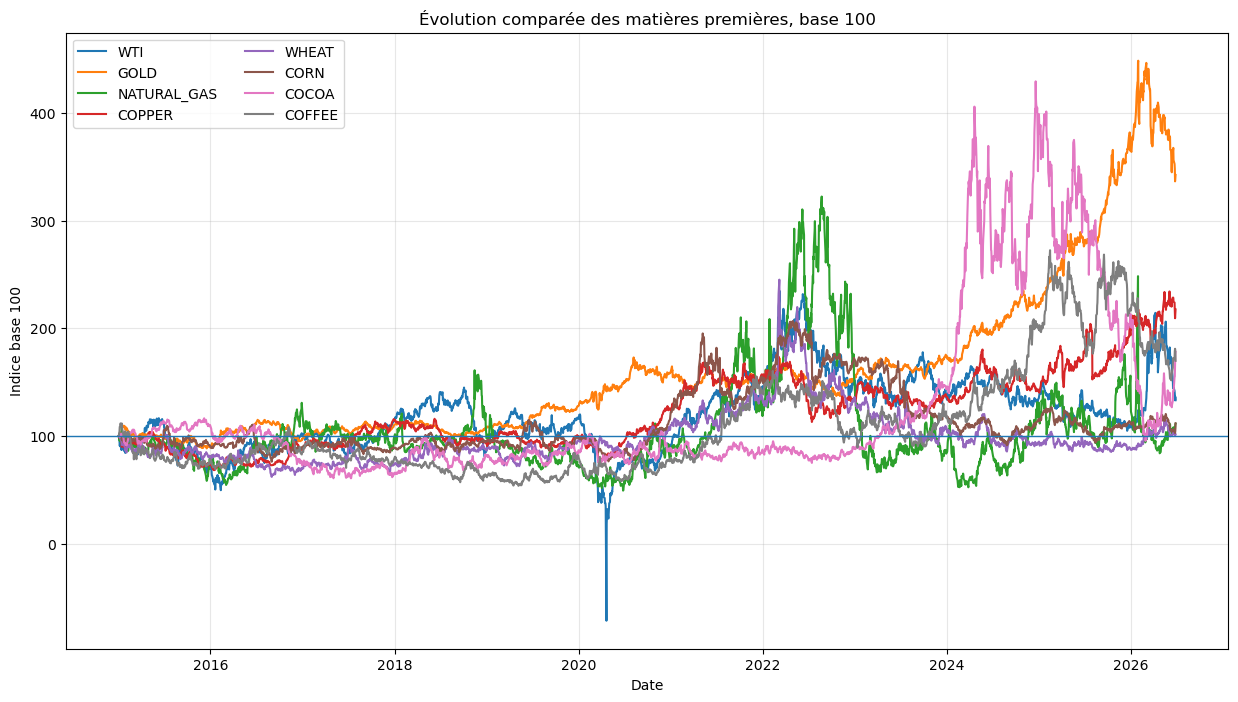

In [8]:
base_100_prices = aligned_prices.divide(aligned_prices.iloc[0]).multiply(BASE_VALUE)

plt.figure(figsize=(15, 8))
for column in base_100_prices.columns:
    plt.plot(base_100_prices.index, base_100_prices[column], label=column)
plt.axhline(BASE_VALUE, linewidth=1)
plt.title("Évolution comparée des matières premières, base 100")
plt.xlabel("Date")
plt.ylabel("Indice base 100")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Rendements journaliers et distribution

In [9]:
daily_returns = aligned_prices.pct_change(fill_method=None)

daily_returns.describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
WTI,"2,887.0000",-0.0008,0.0683,-3.0597,-0.0771,-0.0406,0.0015,0.0385,0.0729,0.3766
GOLD,"2,887.0000",0.0005,0.0104,-0.1137,-0.0279,-0.0162,0.0005,0.0161,0.0281,0.0608
NATURAL_GAS,"2,887.0000",0.0009,0.0419,-0.4748,-0.1014,-0.0611,0.0003,0.0639,0.1118,0.4648
COPPER,"2,887.0000",0.0004,0.0153,-0.2225,-0.0390,-0.0234,0.0002,0.0242,0.0377,0.1325
WHEAT,"2,887.0000",0.0002,0.0196,-0.1068,-0.0419,-0.0284,-0.0005,0.0329,0.0567,0.2178
CORN,"2,887.0000",0.0002,0.0158,-0.1739,-0.0428,-0.0223,0.0000,0.0235,0.0419,0.0802
COCOA,"2,887.0000",0.0005,0.0241,-0.2294,-0.0648,-0.0361,0.0004,0.0360,0.0664,0.1366
COFFEE,"2,887.0000",0.0004,0.0212,-0.0863,-0.0490,-0.0338,0.0000,0.0367,0.0546,0.1003


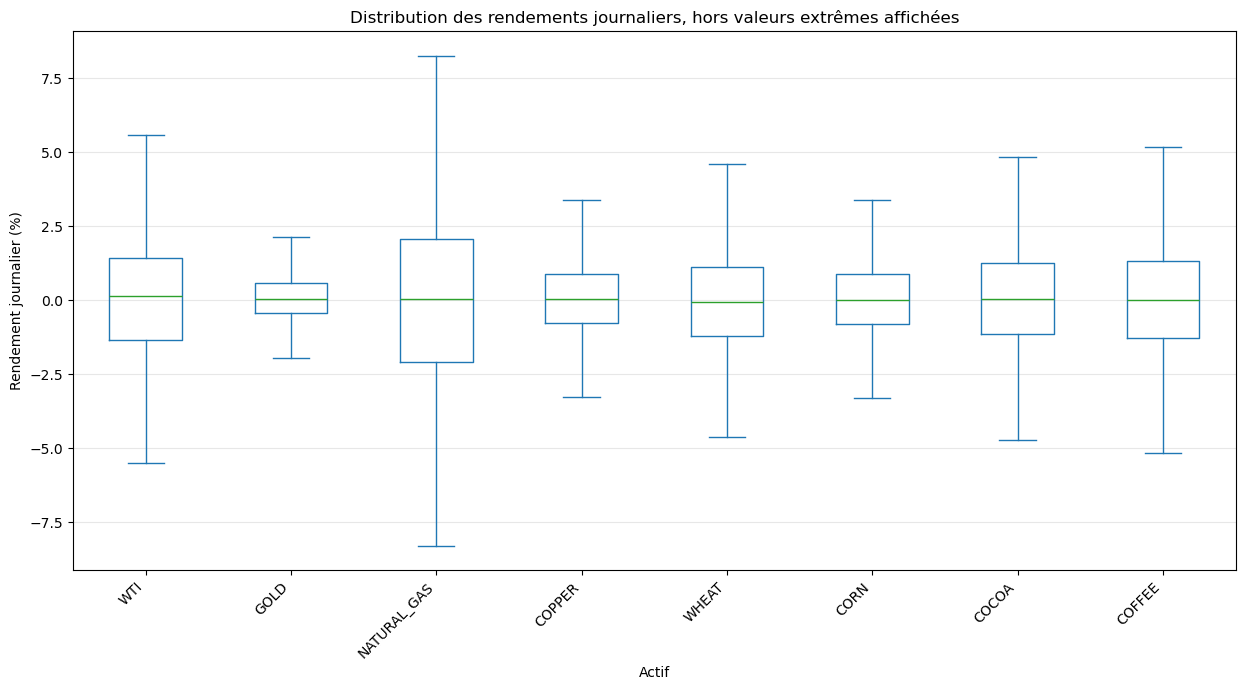

In [10]:
plt.figure(figsize=(15, 7))
daily_returns.multiply(100).plot.box(ax=plt.gca(), showfliers=False)
plt.title("Distribution des rendements journaliers, hors valeurs extrêmes affichées")
plt.xlabel("Actif")
plt.ylabel("Rendement journalier (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 9. Volatilité glissante annualisée

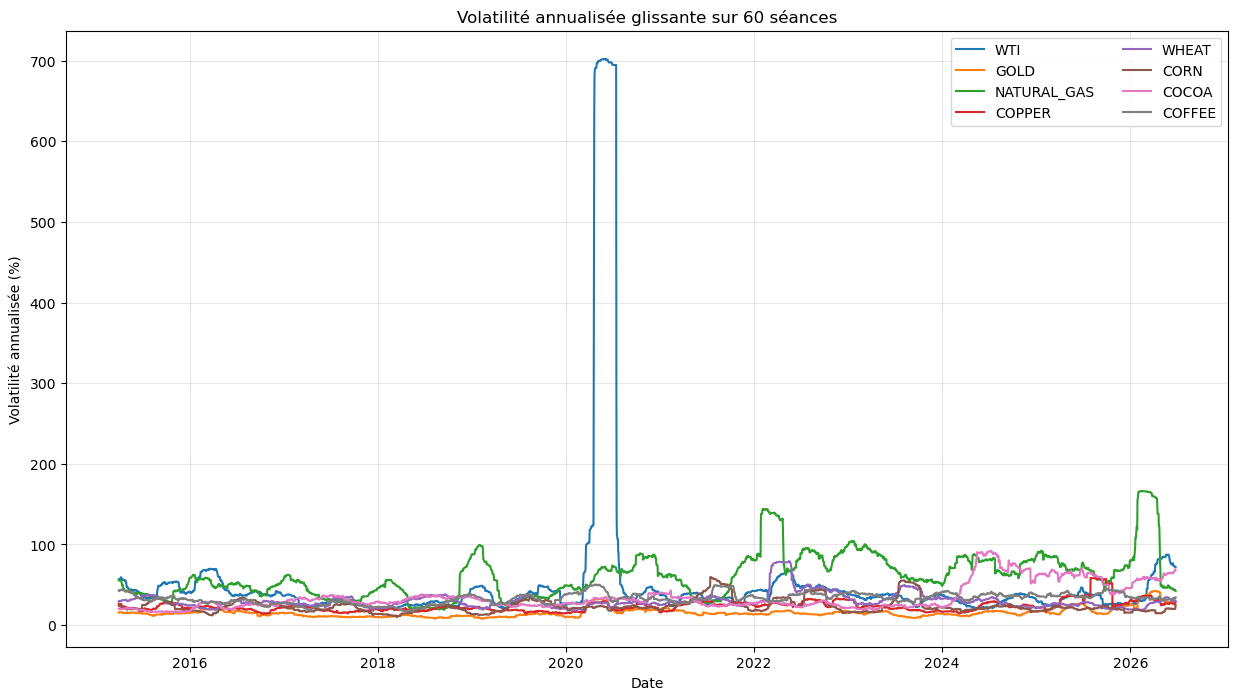

In [11]:
ROLLING_VOL_WINDOW = 60
rolling_volatility = daily_returns.rolling(ROLLING_VOL_WINDOW).std() * np.sqrt(252)

plt.figure(figsize=(15, 8))
for column in rolling_volatility.columns:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[column] * 100,
        label=column,
    )
plt.title(f"Volatilité annualisée glissante sur {ROLLING_VOL_WINDOW} séances")
plt.xlabel("Date")
plt.ylabel("Volatilité annualisée (%)")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

## 10. Corrélation entre les marchés

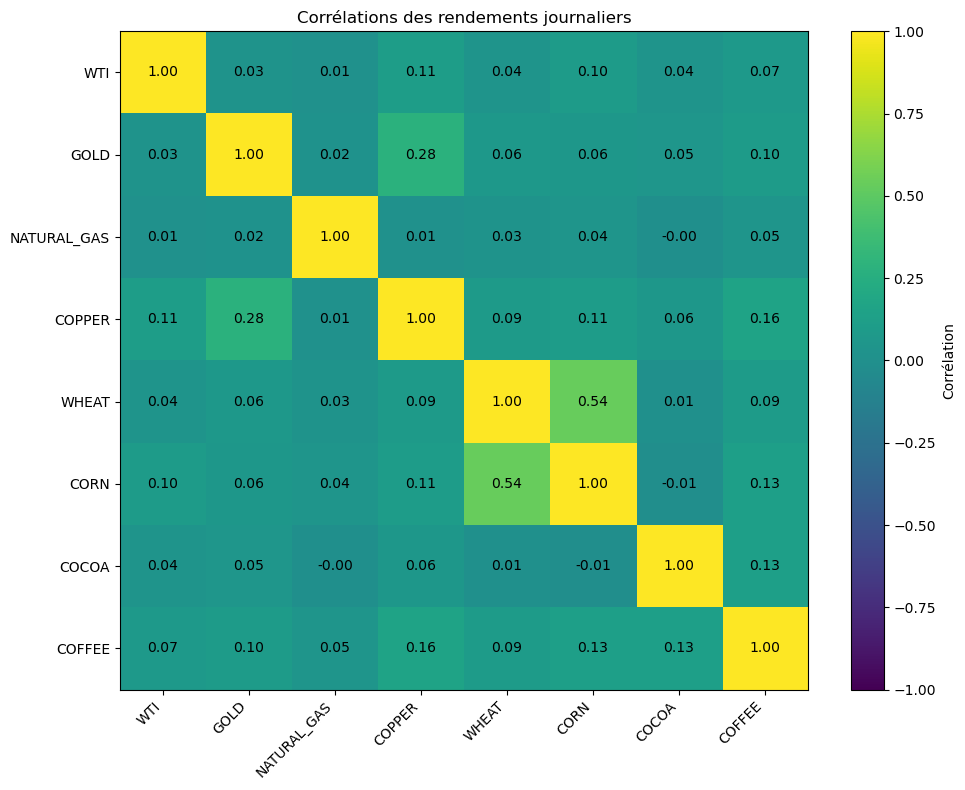

In [12]:
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(10, 8))
image = plt.imshow(correlation_matrix.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(image, label="Corrélation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Corrélations des rendements journaliers")

for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        plt.text(column, row, f"{correlation_matrix.iloc[row, column]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 11. Drawdowns individuels

Le drawdown mesure la baisse depuis le précédent sommet. Il aide à visualiser la profondeur et la durée des crises.

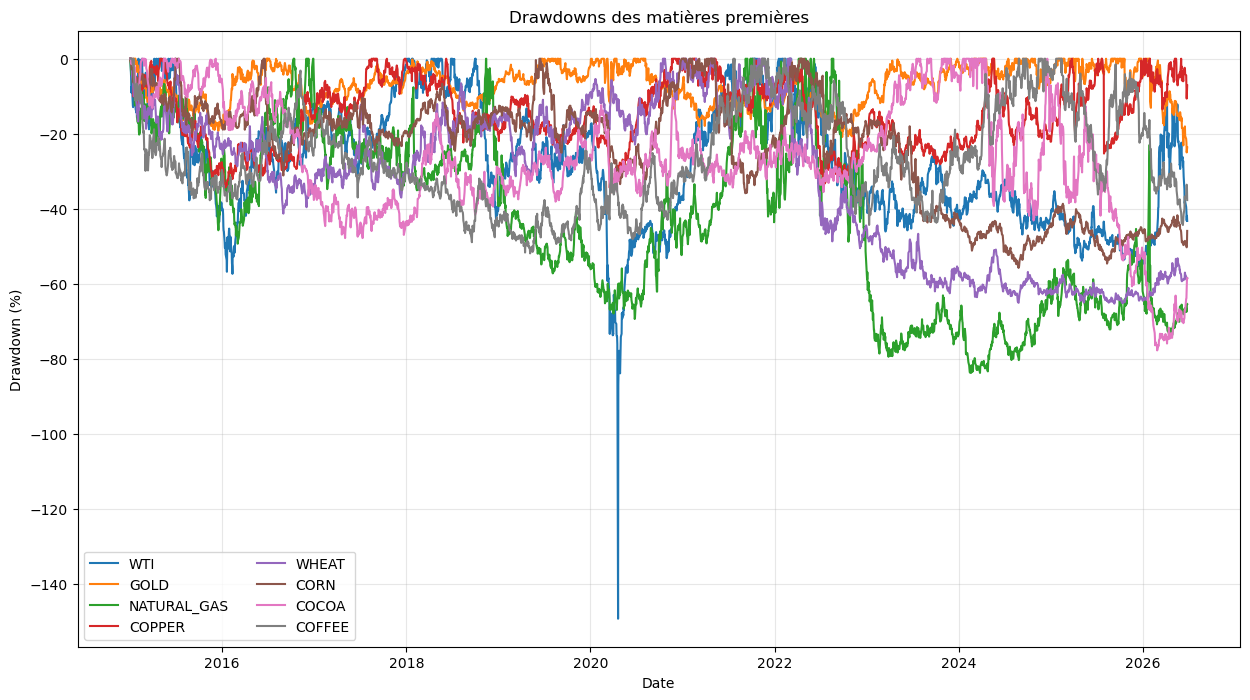

In [13]:
running_peaks = base_100_prices.cummax()
asset_drawdowns = base_100_prices.divide(running_peaks) - 1

plt.figure(figsize=(15, 8))
for column in asset_drawdowns.columns:
    plt.plot(asset_drawdowns.index, asset_drawdowns[column] * 100, label=column)
plt.title("Drawdowns des matières premières")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

## 12. Saisonnalité et comportement mensuel de l'actif étudié

In [14]:
if FOCUS_ASSET not in daily_returns.columns:
    FOCUS_ASSET = daily_returns.columns[0]

focus_monthly_returns = (
    aligned_prices[FOCUS_ASSET]
    .resample("ME")
    .last()
    .pct_change(fill_method=None)
)

monthly_seasonality = pd.DataFrame({
    "mean_return": focus_monthly_returns.groupby(focus_monthly_returns.index.month).mean(),
    "median_return": focus_monthly_returns.groupby(focus_monthly_returns.index.month).median(),
    "positive_month_rate": focus_monthly_returns.groupby(focus_monthly_returns.index.month).apply(lambda s: (s > 0).mean()),
    "observations": focus_monthly_returns.groupby(focus_monthly_returns.index.month).count(),
})
monthly_seasonality.index = [
    "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
    "Juil", "Août", "Sep", "Oct", "Nov", "Déc",
]
monthly_seasonality

,mean_return,median_return,positive_month_rate,observations
Jan,0.0388,0.0586,0.5833,11
Fév,0.0170,0.0252,0.6667,12
Mar,0.0153,0.0361,0.5833,12
Avr,0.0361,0.0402,0.6667,12
Mai,0.0499,-0.0046,0.5000,12
Juin,0.0192,0.0483,0.5833,12
Juil,-0.0169,0.0019,0.5455,11
Août,-0.0183,-0.0560,0.4545,11
Sep,0.0031,-0.0187,0.4545,11
Oct,-0.0064,0.0020,0.5455,11


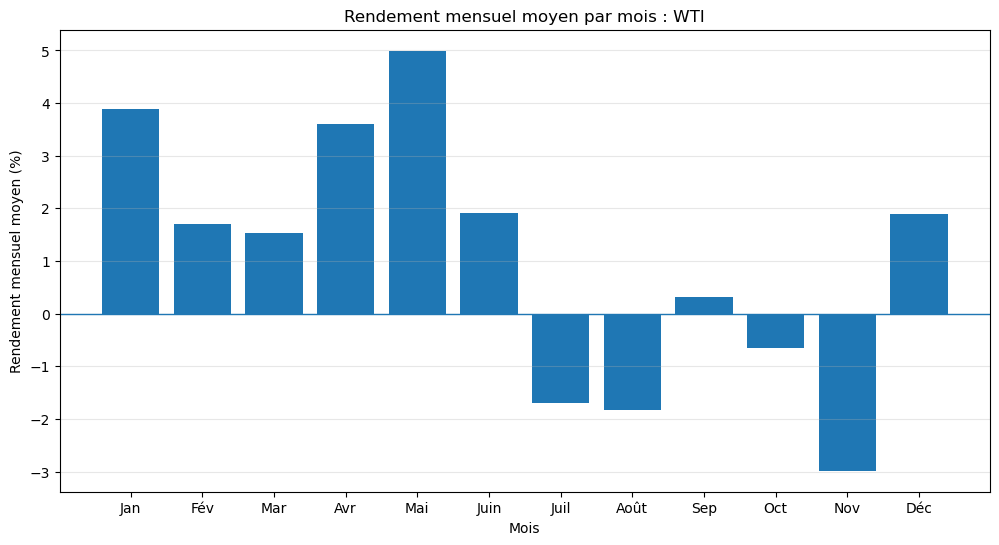

In [15]:
plt.figure(figsize=(12, 6))
plt.bar(monthly_seasonality.index, monthly_seasonality["mean_return"] * 100)
plt.axhline(0, linewidth=1)
plt.title(f"Rendement mensuel moyen par mois : {FOCUS_ASSET}")
plt.xlabel("Mois")
plt.ylabel("Rendement mensuel moyen (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 13. Fonctions de construction de l'indice synthétique

In [16]:
@dataclass(frozen=True)
class IndexConfig:
    base_value: float = 100.0
    weighting: str = "equal"
    rebalance: str = "monthly"
    vol_lookback: int = 60
    min_vol_observations: int = 20
    transaction_cost_bps: float = 0.0
    annual_risk_free_rate: float = 0.0


def calculate_target_weights(
    asset_ids: list[str],
    historical_returns: pd.DataFrame,
    weighting: str,
    vol_lookback: int,
    min_vol_observations: int,
) -> pd.Series:
    if weighting == "equal":
        return pd.Series(1.0 / len(asset_ids), index=asset_ids, dtype=float)

    trailing_returns = historical_returns[asset_ids].tail(vol_lookback)
    valid_counts = trailing_returns.count()
    volatility = trailing_returns.std(ddof=1)

    eligible = (
        valid_counts.ge(min_vol_observations)
        & volatility.notna()
        & np.isfinite(volatility)
        & volatility.gt(0)
    )

    if not eligible.all():
        unavailable = list(eligible.index[~eligible])
        raise ValueError(
            "Volatilité impossible à estimer pour : " + ", ".join(unavailable)
        )

    inverse_volatility = 1.0 / volatility
    return inverse_volatility / inverse_volatility.sum()


def get_rebalance_flags(
    dates: pd.DatetimeIndex,
    rebalance: str,
) -> pd.Series:
    flags = pd.Series(False, index=dates)
    flags.iloc[0] = True

    if rebalance == "none" or len(dates) == 1:
        return flags

    periods = dates.tz_localize(None).to_period(REBALANCE_PERIOD_MAP[rebalance])
    flags.iloc[1:] = np.asarray(periods[1:] != periods[:-1])
    return flags


def build_synthetic_index(
    prices: pd.DataFrame,
    config: IndexConfig,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    asset_ids = list(prices.columns)
    returns = prices.pct_change(fill_method=None)

    if config.weighting == "inverse_vol":
        start_position = max(config.vol_lookback, config.min_vol_observations)
        if len(prices) <= start_position:
            raise ValueError("Historique insuffisant pour la pondération inverse_vol.")
    else:
        start_position = 0

    index_dates = prices.index[start_position:]
    rebalance_flags = get_rebalance_flags(index_dates, config.rebalance)

    units: pd.Series | None = None
    previous_level: float | None = None
    index_records: list[dict[str, Any]] = []
    weight_records: list[dict[str, Any]] = []

    for date in index_dates:
        current_prices = prices.loc[date, asset_ids]
        rebalance_requested = bool(rebalance_flags.loc[date])
        rebalance_executed = False
        rebalance_skipped = False
        turnover = 0.0
        transaction_cost = 0.0
        target_weights: pd.Series | None = None

        full_position = prices.index.get_loc(date)
        historical_returns = returns.iloc[:full_position]

        if units is None:
            if current_prices.le(0).any():
                invalid_assets = list(current_prices.index[current_prices.le(0)])
                raise ValueError(
                    "Prix initial non positif pour : " + ", ".join(invalid_assets)
                )

            target_weights = calculate_target_weights(
                asset_ids,
                historical_returns,
                config.weighting,
                config.vol_lookback,
                config.min_vol_observations,
            )
            units = config.base_value * target_weights / current_prices
            index_level = config.base_value
            gross_index_level = config.base_value
            rebalance_executed = True

        else:
            position_values_before = units * current_prices
            gross_index_level = float(position_values_before.sum())
            index_level = gross_index_level

            if not math.isfinite(gross_index_level):
                raise ValueError(f"Valeur d'indice non finie à la date {date}.")

            if rebalance_requested:
                if gross_index_level <= 0 or current_prices.le(0).any():
                    rebalance_skipped = True
                else:
                    target_weights = calculate_target_weights(
                        asset_ids,
                        historical_returns,
                        config.weighting,
                        config.vol_lookback,
                        config.min_vol_observations,
                    )
                    current_weights = position_values_before / gross_index_level
                    turnover = float(0.5 * (target_weights - current_weights).abs().sum())
                    transaction_cost = float(
                        gross_index_level
                        * turnover
                        * config.transaction_cost_bps
                        / 10_000.0
                    )
                    index_level = gross_index_level - transaction_cost
                    units = index_level * target_weights / current_prices
                    rebalance_executed = True

        position_values_after = units * current_prices
        actual_weights = position_values_after / float(position_values_after.sum())
        daily_return = (
            np.nan
            if previous_level is None
            else index_level / previous_level - 1.0
        )

        index_records.append({
            "date": date,
            "index_level": index_level,
            "gross_index_level": gross_index_level,
            "daily_return": daily_return,
            "rebalance_requested": rebalance_requested,
            "rebalance_executed": rebalance_executed,
            "rebalance_skipped": rebalance_skipped,
            "turnover": turnover,
            "transaction_cost": transaction_cost,
        })

        for asset_id in asset_ids:
            weight_records.append({
                "date": date,
                "asset_id": asset_id,
                "actual_weight": float(actual_weights[asset_id]),
                "target_weight": (
                    float(target_weights[asset_id])
                    if target_weights is not None
                    else np.nan
                ),
                "rebalance_executed": rebalance_executed,
            })

        previous_level = index_level

    index_df = pd.DataFrame(index_records).set_index("date")
    index_df["running_peak"] = index_df["index_level"].cummax()
    index_df["drawdown"] = index_df["index_level"] / index_df["running_peak"] - 1

    weights_df = pd.DataFrame(weight_records)
    return index_df, weights_df


def build_buy_and_hold_indices(
    prices: pd.DataFrame,
    start_date: pd.Timestamp,
    base_value: float,
) -> pd.DataFrame:
    comparable_prices = prices.loc[start_date:].copy()
    initial_prices = comparable_prices.iloc[0]

    if initial_prices.eq(0).any():
        raise ValueError("Un prix initial est nul.")

    buy_hold = comparable_prices.divide(initial_prices).multiply(base_value)
    buy_hold.columns = [f"BH_{asset_id}" for asset_id in buy_hold.columns]
    return buy_hold

## 14. Construction de l'indice et des Buy & Hold

In [17]:
index_config = IndexConfig(
    base_value=BASE_VALUE,
    weighting=WEIGHTING,
    rebalance=REBALANCE,
    vol_lookback=VOL_LOOKBACK,
    min_vol_observations=MIN_VOL_OBSERVATIONS,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    annual_risk_free_rate=ANNUAL_RISK_FREE_RATE,
)

synthetic_index_df, weights_df = build_synthetic_index(
    prices=aligned_prices,
    config=index_config,
)

buy_hold_df = build_buy_and_hold_indices(
    prices=aligned_prices,
    start_date=synthetic_index_df.index[0],
    base_value=BASE_VALUE,
)

comparison_df = pd.concat(
    [
        synthetic_index_df["index_level"].rename("SYNTHETIC_INDEX"),
        buy_hold_df,
    ],
    axis=1,
    join="inner",
)

comparison_df.tail()

,SYNTHETIC_INDEX,BH_WTI,BH_GOLD,BH_NATURAL_GAS,BH_COPPER,BH_WHEAT,BH_CORN,BH_COCOA,BH_COFFEE
2026-06-22 00:00:00+00:00,271.6106,142.0004,352.6054,108.3250,223.9387,102.7957,103.9798,154.5951,171.9963
2026-06-23 00:00:00+00:00,269.1999,138.9448,348.2209,104.7952,216.3467,100.9462,103.5376,155.2784,178.7954
2026-06-24 00:00:00+00:00,270.1732,133.4978,336.4503,107.2594,209.3711,100.7742,102.8427,167.4752,181.0307
2026-06-25 00:00:00+00:00,275.8819,136.4965,339.8398,111.3220,213.8630,101.6774,104.8010,176.2556,179.3232
2026-06-26 00:00:00+00:00,276.7117,133.2511,342.4030,111.5218,217.5621,101.5914,111.8762,178.1346,169.8541


## 15. Comparaison de l'indice synthétique et des Buy & Hold

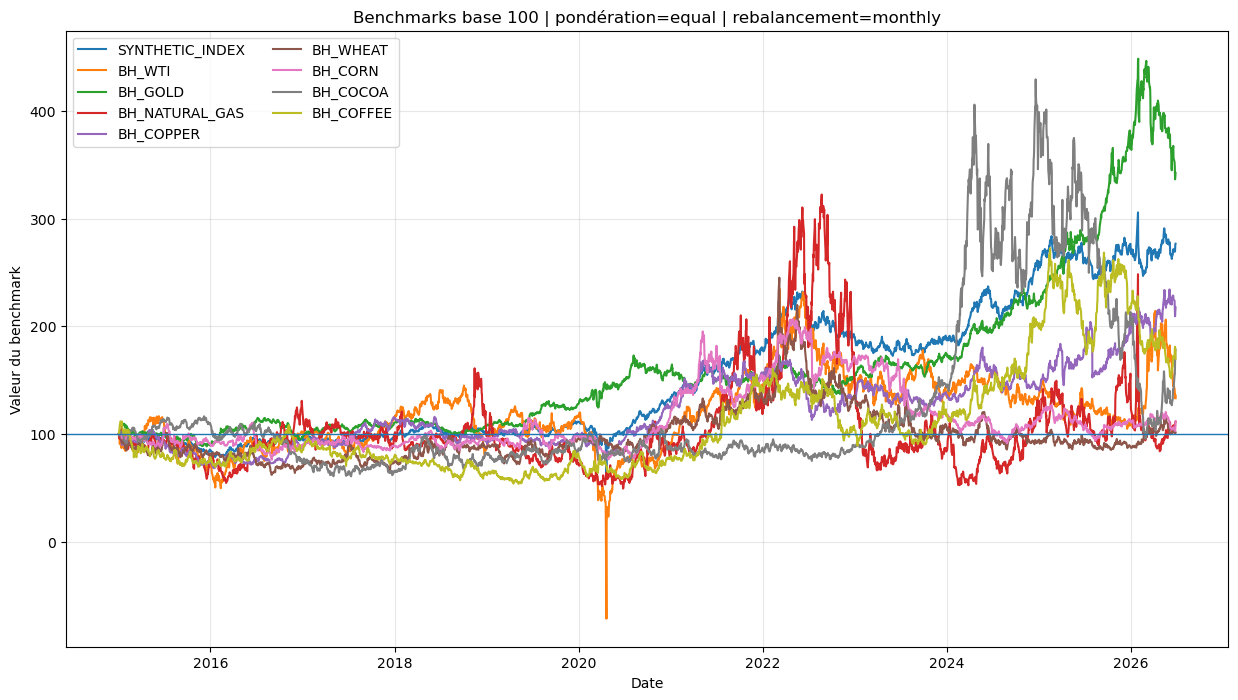

In [18]:
plt.figure(figsize=(15, 8))
for column in comparison_df.columns:
    plt.plot(comparison_df.index, comparison_df[column], label=column)
plt.axhline(BASE_VALUE, linewidth=1)
plt.title(
    f"Benchmarks base {BASE_VALUE:.0f} | pondération={WEIGHTING} | rebalancement={REBALANCE}"
)
plt.xlabel("Date")
plt.ylabel("Valeur du benchmark")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

## 16. Métriques de performance et de risque

In [19]:
def calculate_series_metrics(
    series: pd.Series,
    annual_risk_free_rate: float = 0.0,
    annualization_factor: int = 252,
) -> dict[str, Any]:
    clean = pd.to_numeric(series, errors="coerce").dropna()

    if len(clean) < 2:
        return {
            "start_date": None,
            "end_date": None,
            "observations": len(clean),
            "total_return": np.nan,
            "cagr": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "max_drawdown": np.nan,
        }

    returns = clean.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan).dropna()
    total_return = clean.iloc[-1] / clean.iloc[0] - 1

    elapsed_years = (clean.index[-1] - clean.index[0]).days / 365.25
    if elapsed_years > 0 and clean.iloc[0] > 0 and clean.iloc[-1] > 0:
        cagr = (clean.iloc[-1] / clean.iloc[0]) ** (1 / elapsed_years) - 1
    else:
        cagr = np.nan

    annualized_volatility = returns.std(ddof=1) * np.sqrt(annualization_factor)
    risk_free_daily = (1 + annual_risk_free_rate) ** (1 / annualization_factor) - 1
    excess_returns = returns - risk_free_daily

    sharpe_ratio = (
        excess_returns.mean() / returns.std(ddof=1) * np.sqrt(annualization_factor)
        if returns.std(ddof=1) > 0
        else np.nan
    )

    running_peak = clean.cummax()
    drawdown = clean / running_peak.replace(0, np.nan) - 1

    return {
        "start_date": clean.index[0],
        "end_date": clean.index[-1],
        "observations": len(clean),
        "total_return": float(total_return),
        "cagr": float(cagr) if pd.notna(cagr) else np.nan,
        "annualized_volatility": float(annualized_volatility),
        "sharpe_ratio": float(sharpe_ratio),
        "max_drawdown": float(drawdown.min()),
    }


metrics_df = pd.DataFrame([
    {
        "series_id": column,
        **calculate_series_metrics(
            comparison_df[column],
            annual_risk_free_rate=ANNUAL_RISK_FREE_RATE,
        ),
    }
    for column in comparison_df.columns
])

for column in ["total_return", "cagr", "annualized_volatility", "max_drawdown"]:
    metrics_df[f"{column}_pct"] = metrics_df[column] * 100

metrics_df.sort_values("sharpe_ratio", ascending=False)

,series_id,start_date,end_date,observations,total_return,cagr,annualized_volatility,sharpe_ratio,max_drawdown,total_return_pct,cagr_pct,annualized_volatility_pct,max_drawdown_pct
2,BH_GOLD,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,2.4240,0.1132,0.1652,0.7333,-0.2497,242.4030,11.3175,16.5223,-24.9718
0,SYNTHETIC_INDEX,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,1.7671,0.0927,0.2255,0.5068,-0.4534,176.7117,9.2710,22.5495,-45.3413
4,BH_COPPER,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,1.1756,0.0701,0.2427,0.4023,-0.3564,117.5621,7.0056,24.2746,-35.6362
3,BH_NATURAL_GAS,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,0.1152,0.0095,0.6655,0.3494,-0.8373,11.5218,0.9545,66.5488,-83.7293
7,BH_COCOA,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,0.7813,0.0516,0.3831,0.3250,-0.7773,78.1346,5.1581,38.3092,-77.7318
8,BH_COFFEE,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,0.6985,0.0472,0.3362,0.3053,-0.5187,69.8541,4.7229,33.6189,-51.8745
6,BH_CORN,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,0.1188,0.0098,0.2508,0.1659,-0.5576,11.8762,0.9824,25.0836,-55.7592
5,BH_WHEAT,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,0.0159,0.0014,0.3114,0.1588,-0.6527,1.5914,0.1376,31.1410,-65.2693
1,BH_WTI,2015-01-02 00:00:00+00:00,2026-06-26 00:00:00+00:00,2888,0.3325,0.0253,1.0841,-0.1772,-1.4925,33.2511,2.5321,108.4070,-149.2475


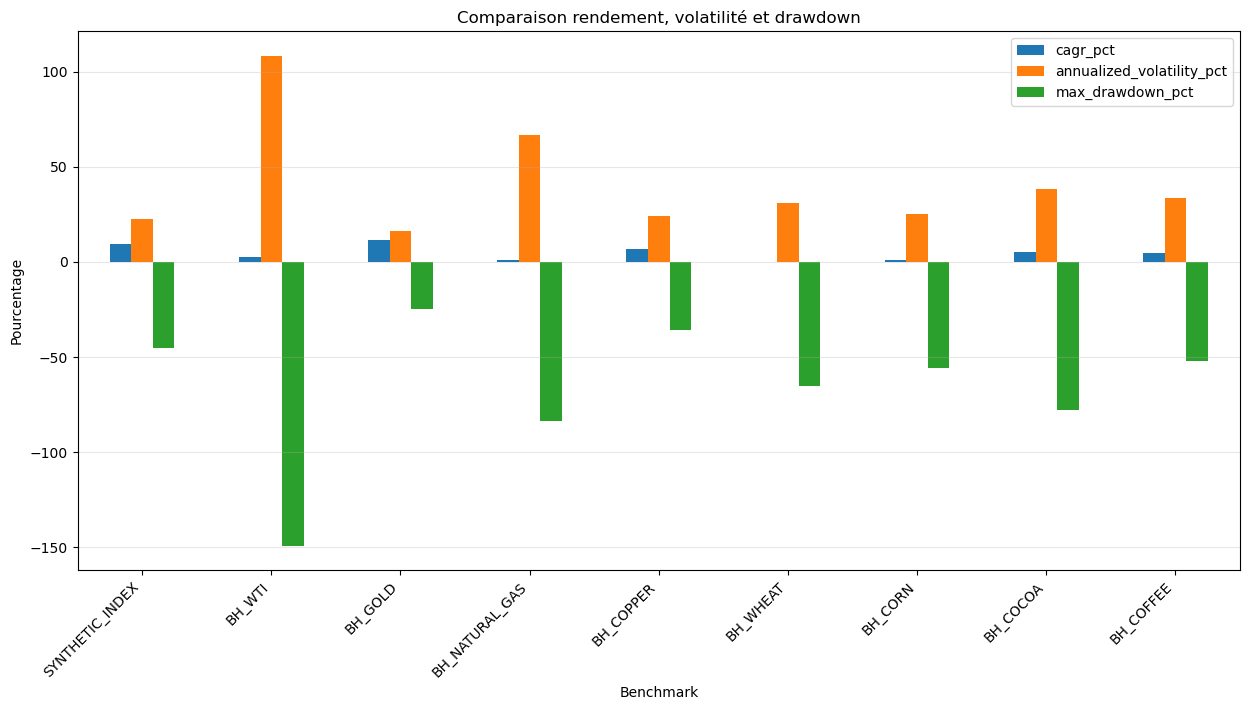

In [20]:
metric_chart = metrics_df.set_index("series_id")[
    ["cagr_pct", "annualized_volatility_pct", "max_drawdown_pct"]
]

plt.figure(figsize=(15, 7))
metric_chart.plot.bar(ax=plt.gca())
plt.title("Comparaison rendement, volatilité et drawdown")
plt.xlabel("Benchmark")
plt.ylabel("Pourcentage")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 17. Drawdown de l'indice synthétique

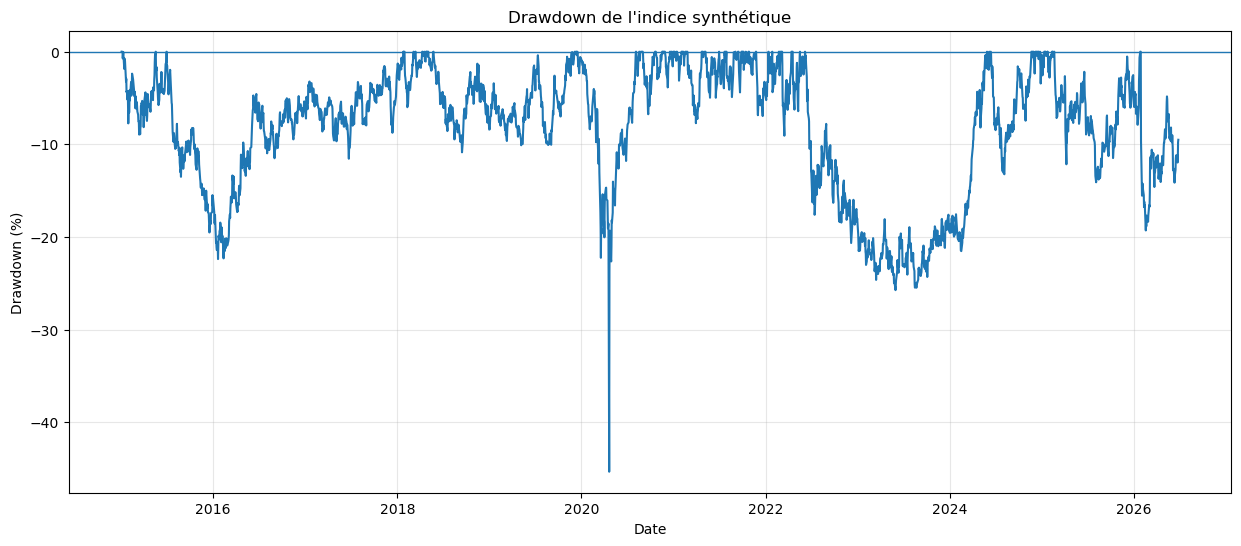

,index_level,drawdown
date,,
2020-04-20 00:00:00+00:00,61.3402,-0.4534
2023-05-31 00:00:00+00:00,172.5402,-0.2574
2023-08-22 00:00:00+00:00,173.1432,-0.2548
2023-08-16 00:00:00+00:00,173.1662,-0.2547
2023-05-30 00:00:00+00:00,173.3152,-0.2540
2023-08-17 00:00:00+00:00,173.6368,-0.2527
2023-06-01 00:00:00+00:00,173.7867,-0.2520
2023-08-21 00:00:00+00:00,173.9612,-0.2513
2023-08-15 00:00:00+00:00,173.9616,-0.2513


In [21]:
plt.figure(figsize=(15, 6))
plt.plot(synthetic_index_df.index, synthetic_index_df["drawdown"] * 100)
plt.axhline(0, linewidth=1)
plt.title("Drawdown de l'indice synthétique")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.show()

synthetic_index_df.nsmallest(10, "drawdown")[["index_level", "drawdown"]]

## 18. Évolution des poids de l'indice

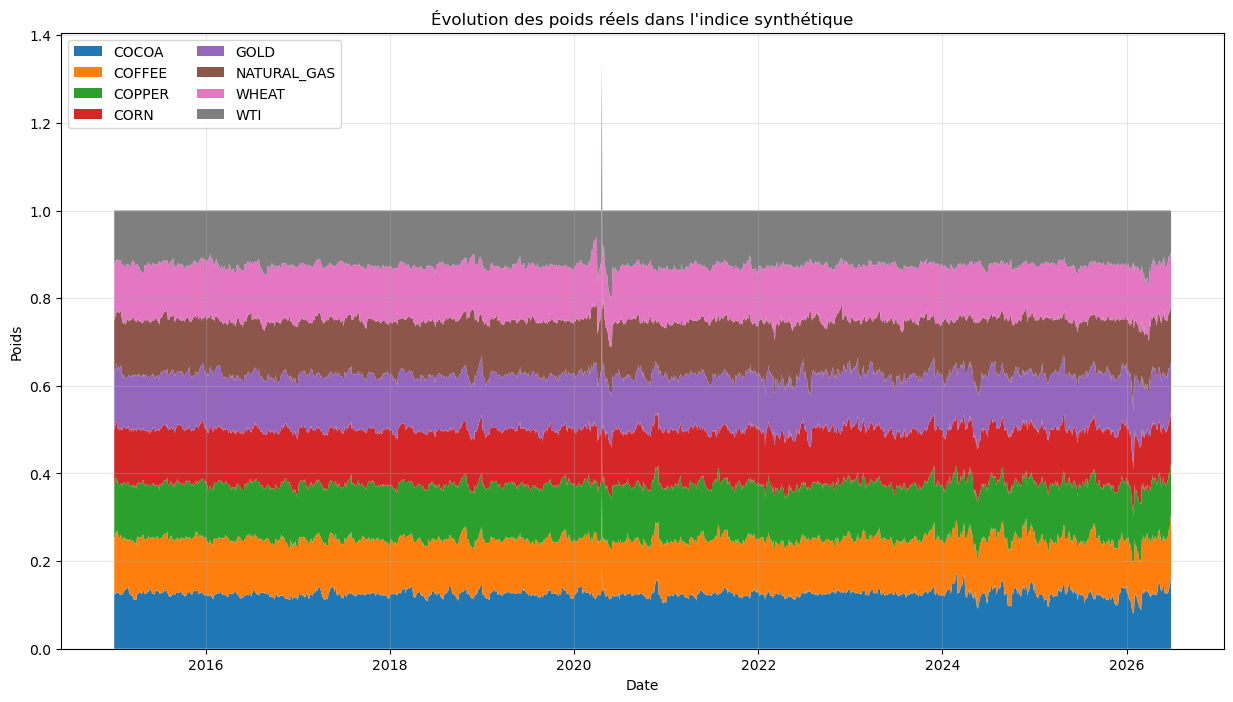

In [22]:
weights_wide = weights_df.pivot(
    index="date",
    columns="asset_id",
    values="actual_weight",
)

plt.figure(figsize=(15, 8))
plt.stackplot(
    weights_wide.index,
    *[weights_wide[column].values for column in weights_wide.columns],
    labels=weights_wide.columns,
)
plt.title("Évolution des poids réels dans l'indice synthétique")
plt.xlabel("Date")
plt.ylabel("Poids")
plt.legend(ncol=2, loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
rebalance_summary = synthetic_index_df.loc[
    synthetic_index_df["rebalance_executed"],
    ["turnover", "transaction_cost"],
].copy()

rebalance_summary.describe()

,turnover,transaction_cost
count,138.0000,138.0000
mean,0.0320,0.0000
std,0.0129,0.0000
min,0.0000,0.0000
25%,0.0226,0.0000
50%,0.0301,0.0000
75%,0.0391,0.0000
max,0.0781,0.0000


## 19. Performances annuelles

In [24]:
annual_levels = comparison_df.resample("YE").last()
annual_returns = annual_levels.pct_change(fill_method=None)

# Inclure la première année depuis le point de départ du benchmark
first_year_returns = annual_levels.iloc[0] / comparison_df.iloc[0] - 1
annual_returns.iloc[0] = first_year_returns
annual_returns.index = annual_returns.index.year
annual_returns.index.name = "year"

annual_returns.multiply(100).round(2)

,SYNTHETIC_INDEX,BH_WTI,BH_GOLD,BH_NATURAL_GAS,BH_COPPER,BH_WHEAT,BH_CORN,BH_COCOA,BH_COFFEE
year,,,,,,,,,
2015,-14.7200,-29.7000,-10.6000,-22.1800,-25.1200,-19.1400,-9.3500,9.7000,-21.3300
2016,11.7400,45.0300,8.4600,59.3500,17.5000,-13.1900,-1.8800,-33.7900,8.1700
2017,3.5500,12.4700,13.5900,-20.7000,31.3100,4.6600,-0.3600,-11.0100,-7.9200
2018,1.1500,-24.8400,-2.1400,-0.4400,-19.8700,17.8600,6.9100,27.7000,-19.2900
2019,11.5500,34.4600,18.8700,-25.5400,6.3200,11.0300,3.4000,5.1300,27.3400
2020,20.5600,-20.5400,24.5900,15.9900,25.7700,14.6300,24.8200,2.4800,-1.1200
2021,32.3300,55.0100,-3.4700,46.9100,26.7800,20.3400,22.5700,-3.1900,76.3000
2022,7.2600,6.7100,-0.4300,19.9700,-14.5800,2.7600,14.3700,3.1700,-26.0100
2023,-1.5800,-10.7300,13.3400,-43.8200,1.9700,-20.7100,-30.5500,61.3800,12.5500


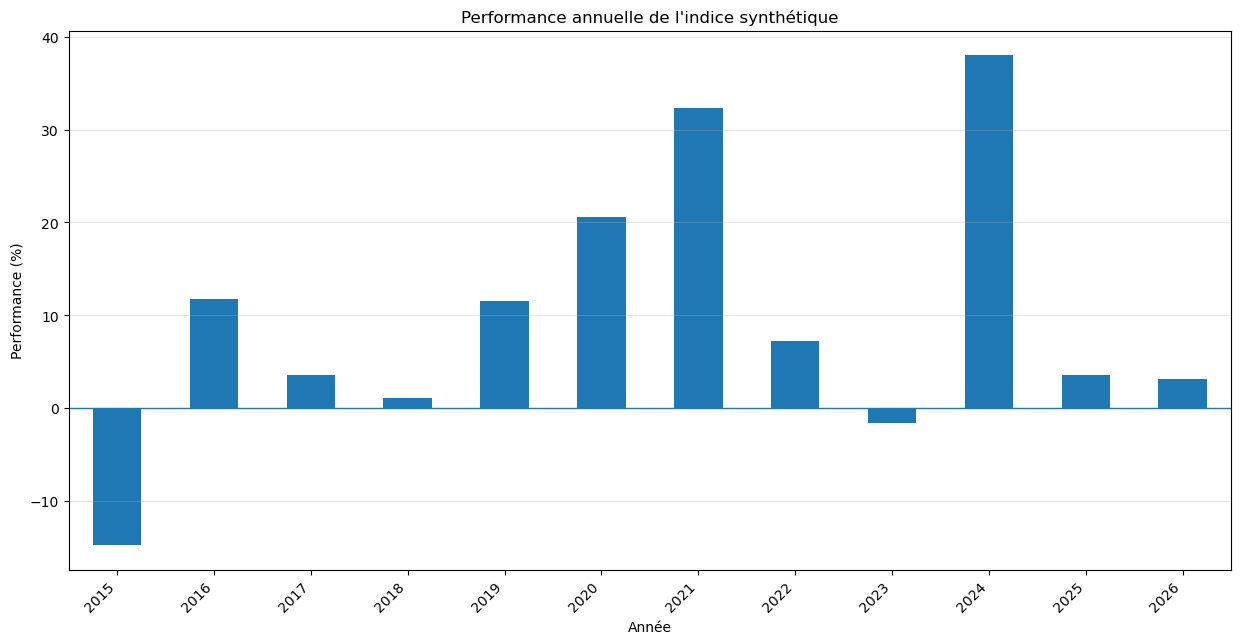

In [25]:
plt.figure(figsize=(15, 7))
annual_returns["SYNTHETIC_INDEX"].multiply(100).plot.bar(ax=plt.gca())
plt.axhline(0, linewidth=1)
plt.title("Performance annuelle de l'indice synthétique")
plt.xlabel("Année")
plt.ylabel("Performance (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 20. Comparaison roulante avec l'indice synthétique

Ce graphique montre quels marchés dominent ou sous-performent l'indice sur une fenêtre glissante d'un an.

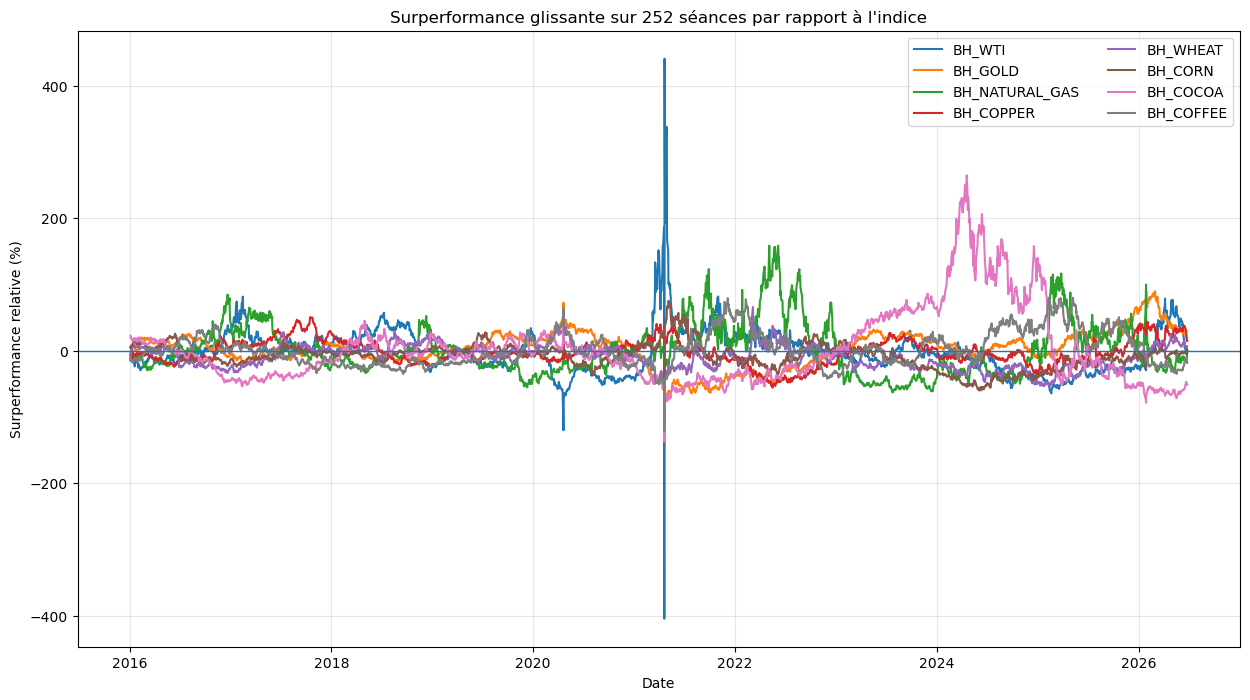

In [26]:
ROLLING_COMPARISON_WINDOW = 252
rolling_performance = comparison_df.divide(
    comparison_df.shift(ROLLING_COMPARISON_WINDOW)
) - 1

relative_to_index = rolling_performance.drop(columns="SYNTHETIC_INDEX").subtract(
    rolling_performance["SYNTHETIC_INDEX"],
    axis=0,
)

plt.figure(figsize=(15, 8))
for column in relative_to_index.columns:
    plt.plot(relative_to_index.index, relative_to_index[column] * 100, label=column)
plt.axhline(0, linewidth=1)
plt.title("Surperformance glissante sur 252 séances par rapport à l'indice")
plt.xlabel("Date")
plt.ylabel("Surperformance relative (%)")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

## 21. Export facultatif des résultats

In [27]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    aligned_prices.to_csv(OUTPUT_DIR / "yfinance_close_prices.csv", date_format="%Y-%m-%d")
    base_100_prices.to_csv(OUTPUT_DIR / "asset_price_indices_base100.csv", date_format="%Y-%m-%d")
    buy_hold_df.to_csv(OUTPUT_DIR / "buy_hold_price_indices.csv", date_format="%Y-%m-%d")
    synthetic_index_df.to_csv(OUTPUT_DIR / "synthetic_commodity_index.csv", date_format="%Y-%m-%d")
    weights_df.to_csv(OUTPUT_DIR / "synthetic_index_weights.csv", index=False, date_format="%Y-%m-%d")
    comparison_df.to_csv(OUTPUT_DIR / "benchmark_comparison.csv", date_format="%Y-%m-%d")
    metrics_df.to_csv(OUTPUT_DIR / "benchmark_metrics.csv", index=False, date_format="%Y-%m-%d")
    quality_report.to_csv(OUTPUT_DIR / "data_quality_report.csv")

    print("Fichiers sauvegardés dans :", OUTPUT_DIR.resolve())
else:
    print("SAVE_OUTPUTS=False : aucun fichier n'a été écrit.")

SAVE_OUTPUTS=False : aucun fichier n'a été écrit.


## Pistes d'exploration suivantes

À partir de ce notebook, tu peux notamment ajouter :

- des signaux de momentum et de retour à la moyenne ;
- une comparaison avec ton futur portefeuille de trading ;
- des variables issues des flux RSS ;
- des régressions entre matières premières et variables macroéconomiques ;
- des tests de régime de marché ;
- une version walk-forward avec réentraînement périodique.

La colonne `SYNTHETIC_INDEX` de `comparison_df` constitue le benchmark global. Les colonnes `BH_*` servent de benchmarks individuels pour chaque marché.